<a href="https://colab.research.google.com/github/JulianaMarqui1/LSTM/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Projeto 5:** Previsão climática utilizando redes neurais recorrentes

In [ ]:
#Biblioteca de aprendizado de máquina
from tensorflow import keras
from tensorflow.keras import layers
from keras.datasets import imdb
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM, SimpleRNN, GRU
from keras.layers import Dropout
from keras.layers import Embedding
from keras.preprocessing import sequence
from sklearn.preprocessing import MinMaxScaler

#Biblioteca de computação científica
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



##Etapa 1:
Download do dataset Jena Climate.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Replace with the actual path to your folder in Google Drive
folder_path = '/content/drive/MyDrive/Colab Notebooks/Projeto5/archive'

try:
    # List all files and directories in the specified folder
    contents = os.listdir(folder_path)
    print(f"Contents of '{folder_path}':")
    for item in contents:
        print(item)
except FileNotFoundError:
    print(f"Error: Folder not found at '{folder_path}'. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Mounted at /content/drive
Contents of '/content/drive/MyDrive/Colab Notebooks/Projeto5/archive':
jena_climate_2009_2016.csv


In [ ]:
file_path = f"{folder_path}/jena_climate_2009_2016.csv"
data = pd.read_csv(file_path)
print("Estrutura dataset: ")
print(data.head())
print(f"\nColunas ({len(data.columns)}): {data.columns.tolist()}")
print(f"Shape: {data.shape}")

Estrutura dataset: 
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.

##Etapa 2:
 Indexação dos dados temporalmente e considerar somente a variável temperatura.

In [ ]:

if 'Date Time' in data.columns:
    data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S')
    data = data.set_index('Date Time')

data = data.sort_index()

temperature = data[["T (degC)"]]

print(f"Indexação dos dados temporalmente: {data.shape}")
print(f"Variável temperatura: {temperature.shape}")


Indexação dos dados temporalmente: (420551, 14)
Variável temperatura: (420551, 1)


In [ ]:
print(type(data.index))
print(data.index[:5])

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2009-01-01 00:10:00', '2009-01-01 00:20:00',
               '2009-01-01 00:30:00', '2009-01-01 00:40:00',
               '2009-01-01 00:50:00'],
              dtype='datetime64[ns]', name='Date Time', freq=None)


Temperatura: 
                      T (degC)
Date Time                    
2009-01-01 00:10:00     -8.02
2009-01-01 00:20:00     -8.41
2009-01-01 00:30:00     -8.51
2009-01-01 00:40:00     -8.31
2009-01-01 00:50:00     -8.27
2009-01-01 01:00:00     -8.05
2009-01-01 01:10:00     -7.62
2009-01-01 01:20:00     -7.62
2009-01-01 01:30:00     -7.91
2009-01-01 01:40:00     -8.43
Nulos  : 0
Mín    : -23.01 °C
Máx    : 37.28 °C
Média  : 9.45 °C


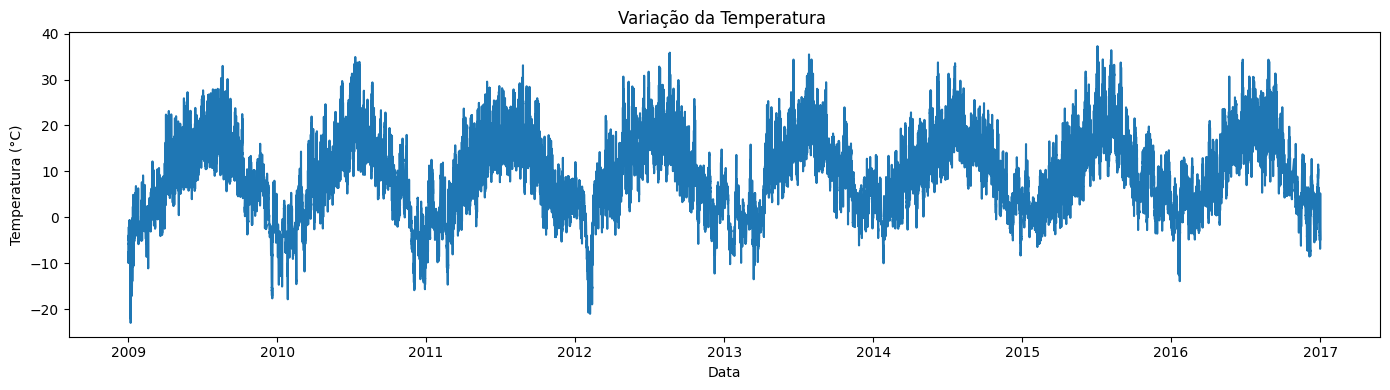

In [ ]:
#análise dos dados de temperatura
print("Temperatura: \n", temperature.head(10))
print(f"Nulos  : {temperature.isnull().sum().values[0]}")
print(f"Mín    : {temperature.min().values[0]:.2f} °C")
print(f"Máx    : {temperature.max().values[0]:.2f} °C")
print(f"Média  : {temperature.mean().values[0]:.2f} °C")

plt.figure(figsize=(14, 4))
plt.plot(temperature)
plt.title("Variação da Temperatura ")
plt.xlabel("Data")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

In [ ]:
#reduzindo o dataset pela metade para facilitar o processamento
n_total = len(temperature)
temperature = temperature.iloc[n_total // 2:]

print(f"Dataset reduzido pela metade: {temperature.shape}")
print(f"Período: {temperature.index.min()} → {temperature.index.max()}")

Dataset reduzido pela metade: (210276, 1)
Período: 2012-12-30 06:20:00 → 2017-01-01 00:00:00


##Etapa3:
Particionar a base de dados sendo 80% dos dados para treinar, 15% para validar, e 5% para testar.

In [ ]:
n = len(temperature)
x_train = temperature[:int(n*0.80)]
x_val = temperature[int(n*0.80):int(n*0.80)+int(n*0.15)]
x_test = temperature[int(n*0.80)+int(n*0.15):]

print(f"Treino: {x_train.shape}")
print(f"Validação: {x_val.shape}")
print(f"Teste: {x_test.shape}")

Treino: (168220, 1)
Validação: (31541, 1)
Teste: (10515, 1)


##Etapa 4:
Implementar uma rede recorrente do tipo LSTM ou GRU capaz de receber a série temporal da variável temperatura e prever a temperatura da próxima amostra (próximos 10 minutos).

- Será implementada uma rede recorrente do tipo LSTM pois se trata de uma sequência longa com armazenamento de memória d elongo prazo.

In [ ]:
#normalização
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(x_train)
val_scaled   = scaler.transform(x_val)
test_scaled  = scaler.transform(x_test)

# uma série temporal de 24h para prever os próximos 10 min
# como cada amostra = 10 min, lookback=144 = últimas 24 horas
LOOKBACK = 144

def windows(serie, lookback):
    X, y = [], []
    for i in range(lookback, len(serie)):
        X.append(serie[i - lookback:i, 0])   # janela de entrada
        y.append(serie[i, 0])                 # próxima amostra
    return np.array(X), np.array(y)

X_train, y_train = windows(train_scaled, LOOKBACK)
X_val,   y_val   = windows(val_scaled,   LOOKBACK)
X_test,  y_test  = windows(test_scaled,  LOOKBACK)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0],     X_val.shape[1],   1)
X_test  = X_test.reshape(X_test.shape[0],   X_test.shape[1],  1)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

X_train : (168076, 144, 1)  |  y_train : (168076,)
X_val   : (31397, 144, 1)    |  y_val   : (31397,)
X_test  : (10371, 144, 1)   |  y_test  : (10371,)


In [ ]:
 #LSTM
model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(32, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
    layers.LSTM(16, return_sequences=False, dropout=0.3, recurrent_dropout=0.2),
    layers.Dense(16, activation="tanh"),
    layers.Dense(1)
])

 #Callback
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

model.summary()

#early_stop = keras.callbacks.EarlyStopping(
#   monitor="val_loss",
#   patience=5,               # para se não melhorar em 5 épocas
#   restore_best_weights=True
#)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,               # reduz LR pela metade
    patience=3,
    min_lr=1e-6
)

# Treinamento
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[ reduce_lr], #early_stop,
    verbose=1
)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 144, 32)        │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,777 (30.38 KB)

 Trainable params: 7,777 (30.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 229s 339ms/step - loss: 0.0142 - mae: 0.0834 - val_loss: 0.0257 - val_mae: 0.1551 - learning_rate: 0.0010
Epoch 2/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 258s 333ms/step - loss: 0.0058 - mae: 0.0489 - val_loss: 0.0279 - val_mae: 0.1622 - learning_rate: 0.0010
Epoch 3/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 217s 330ms/step - loss: 0.0045 - mae: 0.0415 - val_loss: 0.0286 - val_mae: 0.1637 - learning_rate: 0.0010
Epoch 4/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 217s 331ms/step - loss: 0.0040 - mae: 0.0392 - val_loss: 0.0274 - val_mae: 0.1602 - learning_rate: 0.0010
Epoch 5/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 217s 330ms/step - loss: 0.0032 - mae: 0.0342 - val_loss: 0.0267 - val_mae: 0.1580 - learning_rate: 5.0000e-04
Epoch 6/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 218s 332ms/step - loss: 0.0030 - mae: 0.0324 - val_loss: 0.0264 - val_mae: 0.1571 - learning_rate: 5.0000e-04
Epoch 7/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 218s 331ms/step - loss: 0.0028 - mae: 0.0314 - val_loss: 0.0278 - val_mae: 0

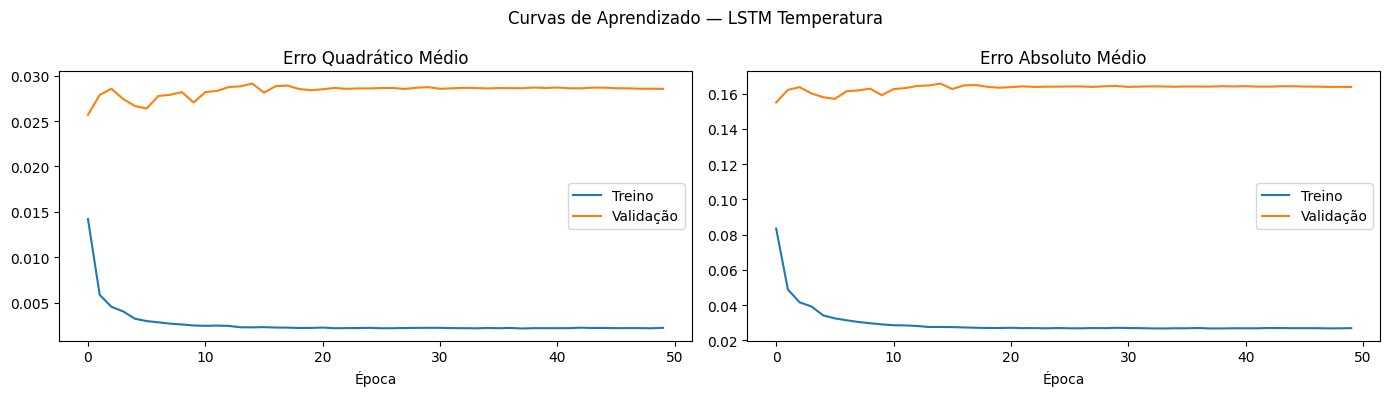


 Avaliação no Teste 
Erro Quadrático Médio  : 0.010638
Erro Absoluto Médio  : 0.098561  (escala normalizada)
325/325 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step
Erro Absoluto Médio  : 5.0473 °C  (escala real)


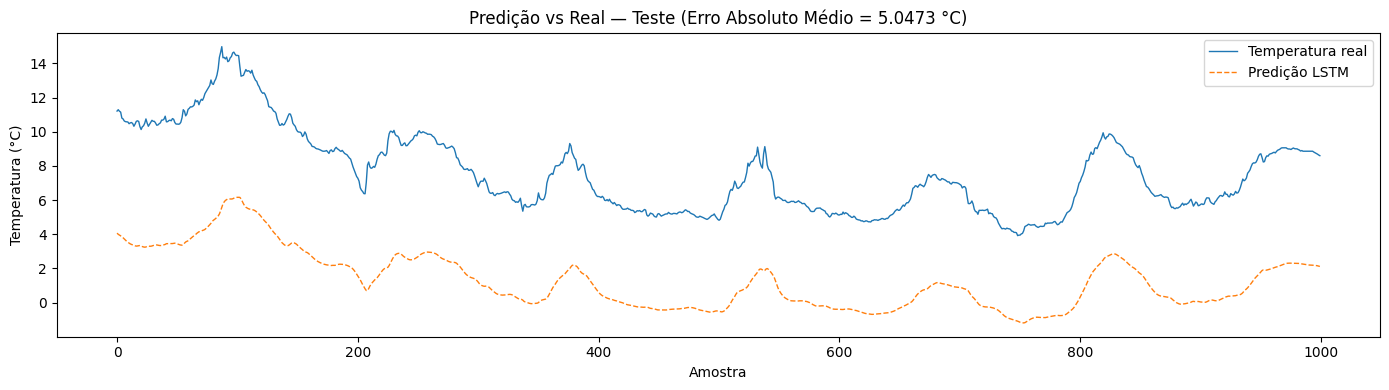

In [ ]:
#Curvas de aprendizado
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history["loss"],     label="Treino")
axes[0].plot(history.history["val_loss"], label="Validação")
axes[0].set_title("Erro Quadrático Médio")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history.history["mae"],     label="Treino")
axes[1].plot(history.history["val_mae"], label="Validação")
axes[1].set_title("Erro Absoluto Médio")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.suptitle("Curvas de Aprendizado — LSTM Temperatura")
plt.tight_layout()
plt.show()

#Avaliação no conjunto de teste
loss_test, mae_test = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Avaliação no Teste ")
print(f"Erro Quadrático Médio  : {loss_test:.6f}")
print(f"Erro Absoluto Médio  : {mae_test:.6f}  (escala normalizada)")

# Predição e desnormalização
y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_real = np.mean(np.abs(y_real - y_pred))
print(f"Erro Absoluto Médio  : {mae_real:.4f} °C  (escala real)")

#Visualização das predições vs real
N_VIS = 1000   # primeiras 1000 amostras do teste para visualizar

plt.figure(figsize=(14, 4))
plt.plot(y_real[:N_VIS],  label="Temperatura real", linewidth=1)
plt.plot(y_pred[:N_VIS],  label="Predição LSTM",    linewidth=1, linestyle="--")
plt.title(f"Predição vs Real — Teste (Erro Absoluto Médio = {mae_real:.4f} °C)")
plt.xlabel("Amostra")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Range das partições")
print(f"Treino  — Mín: {x_train.min().values[0]:.2f}  Máx: {x_train.max().values[0]:.2f}")
print(f"Val     — Mín: {x_val.min().values[0]:.2f}    Máx: {x_val.max().values[0]:.2f}")
print(f"Teste   — Mín: {x_test.min().values[0]:.2f}   Máx: {x_test.max().values[0]:.2f}")

print("\n Períodos")
print(f"Treino  : {x_train.index.min()} → {x_train.index.max()}")
print(f"Val     : {x_val.index.min()}   → {x_val.index.max()}")
print(f"Teste   : {x_test.index.min()}  → {x_test.index.max()}")

print("\n Média de cada partição")
print(f"Treino  : {x_train.mean().values[0]:.2f}")
print(f"Val     : {x_val.mean().values[0]:.2f}")
print(f"Teste   : {x_test.mean().values[0]:.2f}")

Range das partições
Treino  — Mín: -13.93  Máx: 37.28
Val     — Mín: -2.26    Máx: 34.35
Teste   — Mín: -8.55   Máx: 17.48

 Períodos
Treino  : 2012-12-30 06:20:00 → 2016-03-11 20:30:00
Val     : 2016-03-11 20:40:00   → 2016-10-16 21:20:00
Teste   : 2016-10-16 21:30:00  → 2017-01-01 00:00:00

 Média de cada partição
Treino  : 9.63
Val     : 14.55
Teste   : 3.78


Avaliando as métricas dos conjuntos utilizados é possível observar que os conjuntos treino, validação e teste pegaram diferentes estações do ano, ou seja, o modelo foi treinado com os dados da primavera, validado com os dados do verão e testado com os dados do outono. Com essa estratégia o erro absoluto médio foi de aproximadamente 5C.

Para verificar essa questão foi realizado um teste separando os dados por estação. No modelo abaixo foi utilizados os dados apenas do inverno de  2012,2013 e 2014. Essa estratégia fez o erro absoluto médio cair para cerca de 3°C.

Amostras de inverno selecionadas: (26170, 1)
Período: 2012-12-30 06:20:00 → 2014-12-31 23:50:00
Média: 2.22°C
Mín: -10.22°C  |  Máx: 14.47°C

Treino    : 2012-12-30 06:20:00 → 2014-02-23 15:30:00  (20,936 amostras)
Validação : 2014-02-23 15:40:00   → 2014-12-22 21:40:00  (3,925 amostras)
Teste     : 2014-12-22 21:50:00   → 2014-12-31 23:50:00  (1,309 amostras)
Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 36s 350ms/step - loss: 0.0600 - mae: 0.1892 - val_loss: 0.0174 - val_mae: 0.1024 - learning_rate: 0.0010
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 336ms/step - loss: 0.0305 - mae: 0.1403 - val_loss: 0.0194 - val_mae: 0.1158 - learning_rate: 0.0010
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 343ms/step - loss: 0.0197 - mae: 0.1060 - val_loss: 0.0264 - val_mae: 0.1461 - learning_rate: 0.0010
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 331ms/step - loss: 0.0150 - mae: 0.0887 - val_loss: 0.0238 - val_mae: 0.1439 - learning_rate: 0.0010
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 314ms/step - loss: 0.01

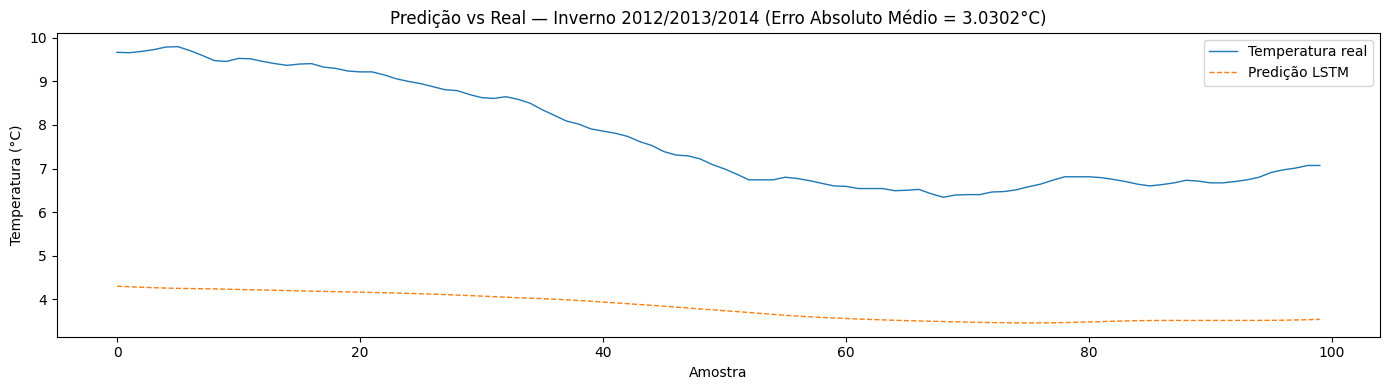

In [ ]:
# apenas os meses de inverno (dez, jan, fev) de 2012
inverno = temperature[
    (temperature.index.month.isin([12, 1, 2])) &
    (temperature.index.year.isin([2012, 2013, 2014]))
]

print(f"Amostras de inverno selecionadas: {inverno.shape}")
print(f"Período: {inverno.index.min()} → {inverno.index.max()}")
print(f"Média: {inverno.mean().values[0]:.2f}°C")
print(f"Mín: {inverno.min().values[0]:.2f}°C  |  Máx: {inverno.max().values[0]:.2f}°C")

n = len(inverno)
x_train_inv = inverno.iloc[:int(n*0.80)]
x_val_inv   = inverno.iloc[int(n*0.80):int(n*0.80)+int(n*0.15)]
x_test_inv  = inverno.iloc[int(n*0.80)+int(n*0.15):]

print(f"\nTreino    : {x_train_inv.index.min()} → {x_train_inv.index.max()}  ({len(x_train_inv):,} amostras)")
print(f"Validação : {x_val_inv.index.min()}   → {x_val_inv.index.max()}  ({len(x_val_inv):,} amostras)")
print(f"Teste     : {x_test_inv.index.min()}   → {x_test_inv.index.max()}  ({len(x_test_inv):,} amostras)")

# Normalização
scaler_inv = MinMaxScaler()
train_scaled_inv = scaler_inv.fit_transform(x_train_inv)
val_scaled_inv   = scaler_inv.transform(x_val_inv)
test_scaled_inv  = scaler_inv.transform(x_test_inv)

# Janelamento
X_train_inv, y_train_inv = windows(train_scaled_inv, LOOKBACK)
X_val_inv,   y_val_inv   = windows(val_scaled_inv,   LOOKBACK)
X_test_inv,  y_test_inv  = windows(test_scaled_inv,  LOOKBACK)

X_train_inv = X_train_inv.reshape(-1, LOOKBACK, 1)
X_val_inv   = X_val_inv.reshape(-1, LOOKBACK, 1)
X_test_inv  = X_test_inv.reshape(-1, LOOKBACK, 1)

# mesma arquitetura utilizada no modelo inicial
model_inv = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(32, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
    layers.LSTM(16, return_sequences=False, dropout=0.3, recurrent_dropout=0.2),
    layers.Dense(16, activation="tanh"),
    layers.Dense(1)
])

model_inv.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse", metrics=["mae"]
)

early_stop_inv = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
reduce_lr_inv = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

history_inv = model_inv.fit(
    X_train_inv, y_train_inv,
    validation_data=(X_val_inv, y_val_inv),
    epochs=50, batch_size=256,
    callbacks=[early_stop_inv, reduce_lr_inv],
    verbose=1
)

# Avaliação
y_pred_inv_scaled = model_inv.predict(X_test_inv)
y_pred_inv = scaler_inv.inverse_transform(y_pred_inv_scaled)
y_real_inv = scaler_inv.inverse_transform(y_test_inv.reshape(-1, 1))

mae_inv = np.mean(np.abs(y_real_inv - y_pred_inv))
print(f"\nErro Absoluto Médio no teste (inverno) : {mae_inv:.4f} °C")

plt.figure(figsize=(14, 4))
plt.plot(y_real_inv[:100], label="Temperatura real", linewidth=1)
plt.plot(y_pred_inv[:100], label="Predição LSTM",    linewidth=1, linestyle="--")
plt.title(f"Predição vs Real — Inverno 2012/2013/2014 (Erro Absoluto Médio = {mae_inv:.4f}°C)")
plt.xlabel("Amostra")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.tight_layout()
plt.show()

## Etapa 5:
 Varie os parâmetros da rede e verifique quais impactos são causados no erro de predição da temperatura na base de teste.

Para encontrar um modelo que converge foi necessário variar os parâmetros, tanto para evitar overfitting, quanto para diminuir o tempo de execução do treinamento. A seguir serão descritas as tecnicas adotadas para a convergência do modelo e os impactos na predição da temperatura.

- Primeiro teste:

Número de neurônios por camada = 64-32-16

Batch size = 256  

Learning rate = 1e-5

Dropout = 0.1

Número de épocas = 50

Esses valores iniciais foram arbitrários e resultaram em um algorítimo extremamente lento, que rodou por cerca de 5 horas e não convergiu. Então, foi adicionado o EarlyStopping com patience=5, que para a execução se o modelo não melhorar em 5 épocas consecutivas.

Conclusão: modelo lento e com overfitting.

- Variação da quantidade de neurônios para diminuir o tempo de execução = 32 - 16- 16.

Diminuir o numero de neurônios por camada deixou o algoritmo um pouco mais rápido, mas o problema de overfitting permaneceu. Neste ponto o modelo parava na época 8, devido ao patience=5, e demorava mais de 1 hora para calcular as 8 épocas.

- Adicionar o  recurrent_dropout

O maior problema era a não convergência do modelo, então adotou-se a estratégia de fazer o dropout = 0.3 e adicionar o recurrent_dropout = 0.2–0.3, que aplica dropout nas conexões recorrentes internas da LSTM. Essa mudança ataca o overfitting de forma mais direta, mas torna o cálculo de cada época mais lento.

Conclusão: melhora na generalização do modelo, mas com aumento no tempo de cada época.

- Variação do Learning rate

Variar o learning rate significa variar o ajuste dos pesos, então valores muito valores muito altos comprometem a estabilidade do treinamento. Por isso, o chute inicial foi um valor baixo (1e-5), mas o modelo estava extremamente lento e a quantidade de épocas estipulada não era suficiente para estabilizar o modelo. Então, foi adotado learning rate = 1e-3 que apresentou o melhor equilíbrio entre velocidade de convergência e estabilidade da loss de validação.

- Variação do batch size: optou-se por utilizar batches maiores, reduzindo a influência de flutuações aleatórias em cada atualização dos pesos.

- Observa-se que a partir da época 10 não apresenta melhoria significativa na precisão, mas para  não precisar rodar o modelo novamente optou-se por ficar com os resultados das 50 épocas.

- No fim, para acelerar a execução o dataset foi dividido ao meio e foram usados os dados dos últimos 5 anos.

- Combinação final:

Número de neurônios por camada = 32-32-16

Batch size = 256  

Learning rate = 1e-3

Dropout = 0.3 e recurrent_dropout = 0.2–0.3

Número de épocas = 50


## Etapa 6:
Altere o janelamento (valor de k) de amostras passadas usadas para predição. O que acontece com a precisão da predição na base de testes?

  O parâmetro k (lookback) define quantas amostras passadas o modelo recebe como contexto para prever o próximo valor. No dataset em análise cada amostra equivale a 10 minutos, então para 1 hora de dados temos k=6.

  Para diminuir o tempo de execução tentei usar k=72, equivalente a 12h, e o modelo ficou menos preciso pois não conseguiu identificar o padrõ diário completo. De forma análoga, se k for muito maior 144 (um dia), os dados terão um padrão repetitivo e isso pode atrapalhar o aprendizado do modelo. O melhor resultado que obtive foi com k=144, equivalente a um dia de amostragem.
  

##Etapa 7:
 Considere somente os dados do ano de 2015 em diante no treinamento do modelo. Como o tamanho da base de dados afeta a predição? Com base nos resultados como você interpreta a relação do passado histórico com a predição do valor atual da ação?


Dataset completo (2009-2016)
  Treino : 2012-12-30 06:20:00 -> 2016-03-11 20:30:00  (168,220 amostras)
  Val    : 2016-03-11 20:40:00 -> 2016-10-16 21:20:00  (31,541 amostras)
  Teste  : 2016-10-16 21:30:00 -> 2017-01-01 00:00:00  (10,515 amostras)
  Épocas treinadas : 6
  Tempo de treino  : 522.5s
  Erro Absoluto Médio teste (°C)   : 5.3192
  RMSE teste (°C)  : 5.5661

Dataset a partir de 2015
  Treino : 2015-01-01 00:00:00 -> 2016-08-05 07:50:00  (83,856 amostras)
  Val    : 2016-08-05 08:00:00 -> 2016-11-25 14:30:00  (15,723 amostras)
  Teste  : 2016-11-25 14:40:00 -> 2017-01-01 00:00:00  (5,241 amostras)
  Épocas treinadas : 7
  Tempo de treino  : 280.7s
  Erro Absoluto Médio teste (°C)   : 3.5781
  RMSE teste (°C)  : 3.9868


COMPARAÇÃO: Dataset completo x A partir de 2015
                 experimento  n_treino anos_treino  epocas  tempo_s    mae_C   rmse_C
Dataset completo (2009-2016)    168220   2012-2016       6    522.5 5.319187 5.566053
    Dataset a partir de 2015     83856

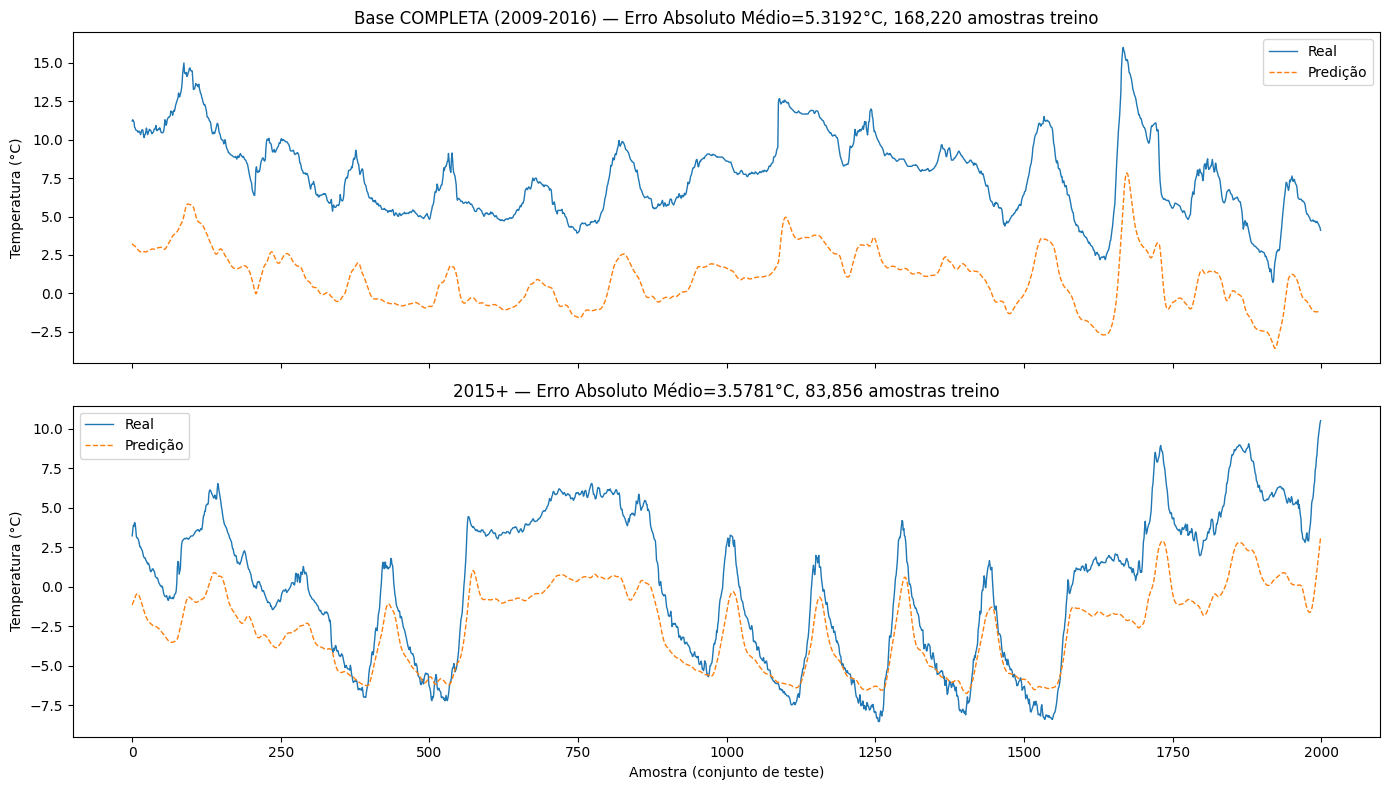

In [ ]:
import time
LOOKBACK = 144

def criar_janelas(serie, lookback):
    X, y = [], []
    for i in range(lookback, len(serie)):
        X.append(serie[i - lookback:i, 0])
        y.append(serie[i, 0])
    return np.array(X), np.array(y)


def construir_modelo(lookback, lstm_units=(32, 16), dropout=0.3, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(lookback, 1)),
        layers.LSTM(lstm_units[0], return_sequences=True, dropout=dropout),
        layers.LSTM(lstm_units[1], return_sequences=False, dropout=dropout),
        layers.Dense(16, activation="tanh"),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )
    return model


def particionar(serie, frac_treino=0.80, frac_val=0.15):
    n = len(serie)
    n_treino = int(n * frac_treino)
    n_val    = int(n * frac_val)
    treino = serie.iloc[:n_treino]
    val    = serie.iloc[n_treino:n_treino + n_val]
    teste  = serie.iloc[n_treino + n_val:]
    return treino, val, teste


def treinar_avaliar(nome, treino_df, val_df, teste_df, lookback=LOOKBACK, epochs=30):
    print(f"\n{'='*60}\n{nome}\n{'='*60}")
    print(f"  Treino : {treino_df.index.min()} -> {treino_df.index.max()}  ({len(treino_df):,} amostras)")
    print(f"  Val    : {val_df.index.min()} -> {val_df.index.max()}  ({len(val_df):,} amostras)")
    print(f"  Teste  : {teste_df.index.min()} -> {teste_df.index.max()}  ({len(teste_df):,} amostras)")

    # normalização
    scaler_local = MinMaxScaler()
    treino_scaled = scaler_local.fit_transform(treino_df)
    val_scaled    = scaler_local.transform(val_df)
    teste_scaled  = scaler_local.transform(teste_df)

    X_tr, y_tr = criar_janelas(treino_scaled, lookback)
    X_v,  y_v  = criar_janelas(val_scaled,   lookback)
    X_te, y_te = criar_janelas(teste_scaled, lookback)

    X_tr = X_tr.reshape(-1, lookback, 1)
    X_v  = X_v.reshape(-1, lookback, 1)
    X_te = X_te.reshape(-1, lookback, 1)

    model = construir_modelo(lookback)
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True
    )

    inicio = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=epochs,
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )
    tempo = time.time() - inicio

    y_pred = model.predict(X_te, verbose=0)
    y_pred_real = scaler_local.inverse_transform(y_pred)
    y_real      = scaler_local.inverse_transform(y_te.reshape(-1, 1))

    mae  = np.mean(np.abs(y_real - y_pred_real))
    rmse = np.sqrt(np.mean((y_real - y_pred_real) ** 2))

    print(f"  Épocas treinadas : {len(history.history['loss'])}")
    print(f"  Tempo de treino  : {tempo:.1f}s")
    print(f"  Erro Absoluto Médio teste (°C)   : {mae:.4f}")
    print(f"  RMSE teste (°C)  : {rmse:.4f}")

    return {
        "experimento": nome,
        "n_treino": len(treino_df),
        "anos_treino": f"{treino_df.index.min().year}-{treino_df.index.max().year}",
        "epocas": len(history.history["loss"]),
        "tempo_s": round(tempo, 1),
        "mae_C": mae,
        "rmse_C": rmse,
        "history": history.history,
        "y_real": y_real,
        "y_pred": y_pred_real
    }

#dataset completo (2009-2016)
treino_full, val_full, teste_full = particionar(temperature)
resultado_full = treinar_avaliar(
    "Dataset completo (2009-2016)",
    treino_full, val_full, teste_full
)

# a partir de 2015
serie_2015 = temperature.loc["2015-01-01":]
treino_2015, val_2015, teste_2015 = particionar(serie_2015)
resultado_2015 = treinar_avaliar(
    "Dataset a partir de 2015",
    treino_2015, val_2015, teste_2015
)

# COMPARAÇÃO

df_comp = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("history", "y_real", "y_pred")}
    for r in [resultado_full, resultado_2015]
])

print("\n\nCOMPARAÇÃO: Dataset completo x A partir de 2015")
print(df_comp.to_string(index=False))

N_VIS = 2000
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(resultado_full["y_real"][:N_VIS], label="Real", linewidth=1)
axes[0].plot(resultado_full["y_pred"][:N_VIS], label="Predição", linewidth=1, linestyle="--")
axes[0].set_title(f"Base COMPLETA (2009-2016) — Erro Absoluto Médio={resultado_full['mae_C']:.4f}°C, "
                   f"{resultado_full['n_treino']:,} amostras treino")
axes[0].legend()
axes[0].set_ylabel("Temperatura (°C)")

axes[1].plot(resultado_2015["y_real"][:N_VIS], label="Real", linewidth=1)
axes[1].plot(resultado_2015["y_pred"][:N_VIS], label="Predição", linewidth=1, linestyle="--")
axes[1].set_title(f"2015+ — Erro Absoluto Médio={resultado_2015['mae_C']:.4f}°C, "
                   f"{resultado_2015['n_treino']:,} amostras treino")
axes[1].legend()
axes[1].set_ylabel("Temperatura (°C)")
axes[1].set_xlabel("Amostra (conjunto de teste)")

plt.tight_layout()
plt.savefig("comparacao_tamanho_base.png", dpi=150)
plt.show()

A predição utilizando os dados apenas de 2015 apresentou erro menor do que a predição utilizando dados de 5 anos passados, mas a predição separada por estação se mostrou mais precisa. A variação de temperatura é muito grande, como analisado no início do projeto, e essa grande variação prejudica o modelo. Talvez se aplicar um método diferente de normalização ou otimização os resultados sejam melhores para um período grande de dados.

##Etapa 8:
 Altere o código para que ele seja capaz de realizar a predição da temperatura para um período maior, por exemplo, o valor da temperatura prevista para a próxima hora (6 saídas - 60 minutos).

In [ ]:

HORIZON  = 6      # quantidade de passos para 60min

# janelamento para multi-step
def criar_janelas_multistep(serie, lookback, horizon):

    X, y = [], []
    for i in range(lookback, len(serie) - horizon + 1):
        X.append(serie[i - lookback:i, 0])
        y.append(serie[i:i + horizon, 0])     # vetor de 6 valores
    return np.array(X), np.array(y)


X_train, y_train = criar_janelas_multistep(train_scaled, LOOKBACK, HORIZON)
X_val,   y_val   = criar_janelas_multistep(val_scaled,   LOOKBACK, HORIZON)
X_test,  y_test  = criar_janelas_multistep(test_scaled,  LOOKBACK, HORIZON)

X_train = X_train.reshape(-1, LOOKBACK, 1)
X_val   = X_val.reshape(-1, LOOKBACK, 1)
X_test  = X_test.reshape(-1, LOOKBACK, 1)

print("=== Shapes (multi-step) ===")
print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"\n→ y agora tem {HORIZON} colunas: uma para cada passo futuro previsto")

model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),

    layers.LSTM(64, return_sequences=True, dropout=0.3),
    layers.LSTM(32, return_sequences=False, dropout=0.3),

    layers.Dense(16, activation="relu"),
    layers.Dense(HORIZON)     #prevê HORIZON valores de uma vez
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

model.summary()

# Treinamento
#early_stop = keras.callbacks.EarlyStopping(
#    monitor="val_loss", patience=5, restore_best_weights=True
#)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[],
    verbose=1
)


loss_test, mae_test_norm = model.evaluate(X_test, y_test, verbose=0)
print(f"\nMSE teste (normalizado) : {loss_test:.6f}")
print(f"Erro Absoluto Médio teste (normalizado) : {mae_test_norm:.6f}")


=== Shapes (multi-step) ===
X_train : (336291, 144, 1)  |  y_train : (336291, 6)
X_val   : (62933, 144, 1)    |  y_val   : (62933, 6)
X_test  : (20880, 144, 1)   |  y_test  : (20880, 6)

→ y agora tem 6 colunas: uma para cada passo futuro previsto


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 144, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,942 (116.96 KB)

 Trainable params: 29,942 (116.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 309s 232ms/step - loss: 0.0096 - mae: 0.0509 - val_loss: 0.0556 - val_mae: 0.2338
Epoch 2/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 308s 234ms/step - loss: 0.0023 - mae: 0.0277 - val_loss: 0.0437 - val_mae: 0.2069
Epoch 3/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 307s 234ms/step - loss: 0.0022 - mae: 0.0263 - val_loss: 0.0477 - val_mae: 0.2171
Epoch 4/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 306s 233ms/step - loss: 0.0022 - mae: 0.0254 - val_loss: 0.0504 - val_mae: 0.2229
Epoch 5/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 303s 231ms/step - loss: 0.0023 - mae: 0.0263 - val_loss: 0.0487 - val_mae: 0.2191
Epoch 6/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 302s 230ms/step - loss: 0.0022 - mae: 0.0246 - val_loss: 0.0540 - val_mae: 0.2312
Epoch 7/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 303s 231ms/step - loss: 0.0021 - mae: 0.0241 - val_loss: 0.0447 - val_mae: 0.2089
Epoch 8/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 305s 232ms/step - loss: 0.0022 - mae: 0.0247 - val_loss: 0.0445 - val_mae: 0.2073
Epoch 9/

NameError: name 'scaler' is not defined

##Etapa 9:
 Considere o problema de predição multivariável, alimente a rede neural com todas as 12 variáveis e obetenha a previsão da temperatura para os próximos 30 minutos (3 saídas) futuros.

A diferença na precisão da predição é impressionante. Utilizando apenas a temeratura o melhor resultado obtido foi de erro absoluto médio de aproximadamente 3°C. Já utilizando todas as 12 variáveis do dataset o erro absoluto médio foi de 0.53 °C. Isso mostra que somente a temperatura é uma variável fraca para fazer a predição de temperatura, mas combinada à umidade do ar, velocidade do vento e pressão atmoférica apresentam um comportamento mais consistente e homogêneo para treinar uma rede LSTM.

<>:106: SyntaxWarning: invalid escape sequence '\ '
<>:106: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_17673/2515020549.py:106: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Avaliação no Teste ")


Colunas disponíveis: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Shape dos dados multivariáveis: (420551, 14)
Número de variáveis (features): 14
Índice da coluna alvo 'T (degC)': 1

Treino    : (336440, 14)
Validação : (63082, 14)
Teste     : (21029, 14)

=== Shapes (multivariável + multi-step) ===
X_train : (336294, 144, 14)  |  y_train : (336294, 3)
X_val   : (62936, 144, 14)    |  y_val   : (62936, 3)
X_test  : (20883, 144, 14)   |  y_test  : (20883, 3)

→ X agora tem 14 features (variáveis) por timestep
→ y tem 3 saídas (previsão da temperatura nos próximos 30 min)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 144, 32)        │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,475 (37.01 KB)

 Trainable params: 9,475 (37.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 200s 148ms/step - loss: 0.0070 - mae: 0.0550 - val_loss: 4.1137e-04 - val_mae: 0.0140 - learning_rate: 0.0010
Epoch 2/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 194s 147ms/step - loss: 0.0019 - mae: 0.0341 - val_loss: 3.4709e-04 - val_mae: 0.0113 - learning_rate: 0.0010
Epoch 3/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 194s 148ms/step - loss: 0.0016 - mae: 0.0311 - val_loss: 4.6411e-04 - val_mae: 0.0126 - learning_rate: 0.0010
Epoch 4/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 193s 147ms/step - loss: 0.0013 - mae: 0.0274 - val_loss: 0.0010 - val_mae: 0.0243 - learning_rate: 0.0010
Epoch 5/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 191s 145ms/step - loss: 0.0010 - mae: 0.0246 - val_loss: 0.0013 - val_mae: 0.0291 - learning_rate: 5.0000e-04
Epoch 6/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 191s 146ms/step - loss: 9.5094e-04 - mae: 0.0234 - val_loss: 0.0022 - val_mae: 0.0422 - learning_rate: 5.0000e-04
Epoch 7/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 191s 145ms/step - loss: 8.2398e-04 - mae: 0.02

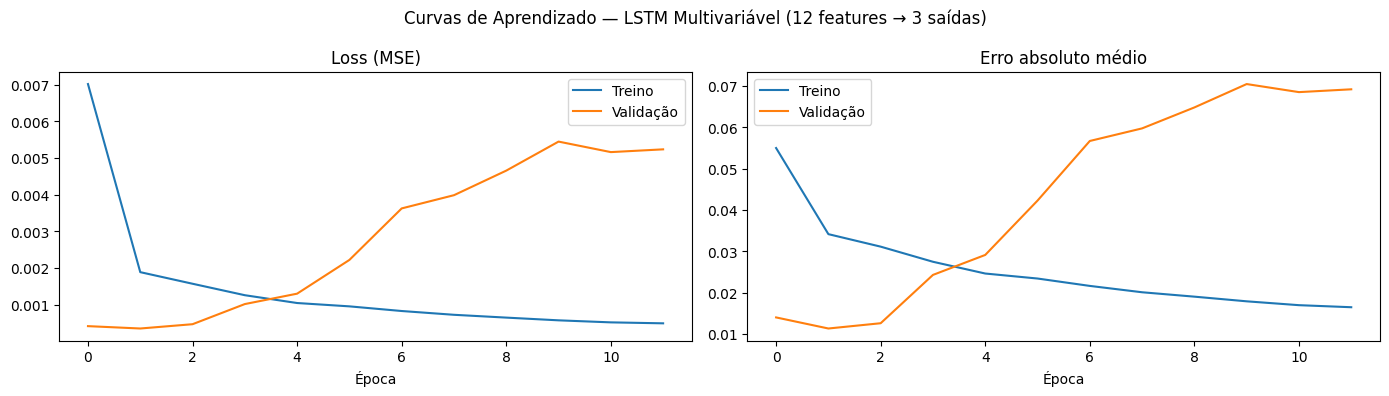

\ Avaliação no Teste 
Erro absoluto quadrático  : 0.000206
Erro absoluto médio  : 0.010075

Erro absoluto médio por passo futuro
  +10min (passo 1/3) : MAE = 0.5245 °C
  +20min (passo 2/3) : MAE = 0.5965 °C
  +30min (passo 3/3) : MAE = 0.6583 °C

MAE médio (todos os passos) : 0.5931 °C


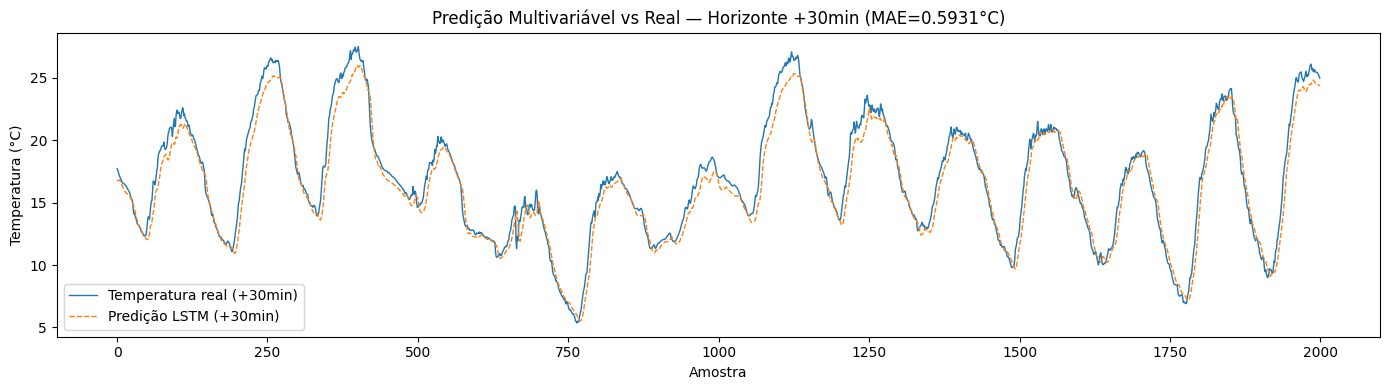

In [ ]:
print(f"Colunas disponíveis: {data.columns.tolist()}")

features = data.copy()   # todas as 12 variáveis (já sem 'Date Time', que é o índice)
print(f"\nShape dos dados multivariáveis: {features.shape}")
print(f"Número de variáveis (features): {features.shape[1]}")

#índice da coluna de temperatura é o target
TARGET_COL = "T (degC)"
idx_temp = features.columns.get_loc(TARGET_COL)
print(f"Índice da coluna alvo '{TARGET_COL}': {idx_temp}")

n = len(features)
train_df = features.iloc[:int(n*0.80)]
val_df   = features.iloc[int(n*0.80):int(n*0.80)+int(n*0.15)]
test_df  = features.iloc[int(n*0.80)+int(n*0.15):]

print(f"\nTreino    : {train_df.shape}")
print(f"Validação : {val_df.shape}")
print(f"Teste     : {test_df.shape}")

# Normalização
scaler_multi = MinMaxScaler()
train_scaled = scaler_multi.fit_transform(train_df)
val_scaled   = scaler_multi.transform(val_df)
test_scaled  = scaler_multi.transform(test_df)

# Janelamento multivariável + multi-step
LOOKBACK = 144
HORIZON  = 3

def criar_janelas_multivariavel(serie, lookback, horizon, idx_target):
    X, y = [], []
    for i in range(lookback, len(serie) - horizon + 1):
        X.append(serie[i - lookback:i, :])              # todas as colunas
        y.append(serie[i:i + horizon, idx_target])       # só a coluna da temperatura
    return np.array(X), np.array(y)


X_train, y_train = criar_janelas_multivariavel(train_scaled, LOOKBACK, HORIZON, idx_temp)
X_val,   y_val   = criar_janelas_multivariavel(val_scaled,   LOOKBACK, HORIZON, idx_temp)
X_test,  y_test  = criar_janelas_multivariavel(test_scaled,  LOOKBACK, HORIZON, idx_temp)

print("\n=== Shapes (multivariável + multi-step) ===")
print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"\n→ X agora tem {X_train.shape[2]} features (variáveis) por timestep")
print(f"→ y tem {HORIZON} saídas (previsão da temperatura nos próximos 30 min)")


n_features = X_train.shape[2]

model_multi = keras.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),

    layers.LSTM(32, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
    layers.LSTM(16, return_sequences=False, dropout=0.3, recurrent_dropout=0.2),

    layers.Dense(16, activation="relu"),
    layers.Dense(HORIZON)   # 3 saídas 10/20/30 min
])

model_multi.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

model_multi.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

# Treinamento
history_multi = model_multi.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_multi.history["loss"],     label="Treino")
axes[0].plot(history_multi.history["val_loss"], label="Validação")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history_multi.history["mae"],     label="Treino")
axes[1].plot(history_multi.history["val_mae"], label="Validação")
axes[1].set_title("Erro absoluto médio")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.suptitle("Curvas de Aprendizado — LSTM Multivariável (12 features → 3 saídas)")
plt.tight_layout()
plt.show()

loss_test, mae_test_norm = model_multi.evaluate(X_test, y_test, verbose=0)
print(f"\ Avaliação no Teste ")
print(f"Erro absoluto quadrático  : {loss_test:.6f}")
print(f"Erro absoluto médio  : {mae_test_norm:.6f}")


def desnormalizar_temperatura(valores_normalizados, scaler, idx_target, n_features):
    n_amostras, horizon = valores_normalizados.shape
    resultado = np.zeros((n_amostras, horizon))

    for h in range(horizon):
        dummy = np.zeros((n_amostras, n_features))
        dummy[:, idx_target] = valores_normalizados[:, h]
        dummy_desnorm = scaler.inverse_transform(dummy)
        resultado[:, h] = dummy_desnorm[:, idx_target]

    return resultado


y_pred_scaled = model_multi.predict(X_test, verbose=0)

y_pred = desnormalizar_temperatura(y_pred_scaled, scaler_multi, idx_temp, n_features)
y_real = desnormalizar_temperatura(y_test,        scaler_multi, idx_temp, n_features)


print("\nErro absoluto médio por passo futuro")
for passo in range(HORIZON):
    mae_passo = np.mean(np.abs(y_real[:, passo] - y_pred[:, passo]))
    minutos = (passo + 1) * 10
    print(f"  +{minutos:>2}min (passo {passo+1}/{HORIZON}) : MAE = {mae_passo:.4f} °C")

mae_geral = np.mean(np.abs(y_real - y_pred))
print(f"\nMAE médio (todos os passos) : {mae_geral:.4f} °C")

N_VIS = 2000
plt.figure(figsize=(14, 4))
plt.plot(y_real[:N_VIS, -1], label="Temperatura real (+30min)", linewidth=1)
plt.plot(y_pred[:N_VIS, -1], label="Predição LSTM (+30min)",    linewidth=1, linestyle="--")
plt.title(f"Predição Multivariável vs Real — Horizonte +30min (MAE={mae_geral:.4f}°C)")
plt.xlabel("Amostra")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.tight_layout()
plt.show()